# 09 · Applications: Safety-Critical Predictions and Better Decisions

*Companion notebook for the chapter* **Applications of BNN — Safety Critical Applications · Making Better Decisions**

Uncertainty is only valuable if it **changes what we do**. This notebook uses a real medical data set (breast-cancer diagnosis, shipped with scikit-learn) to show three uses:

1. **Knowing when not to decide** — refer uncertain cases to a human (selective prediction).
2. **Cost-sensitive decisions** — when missing a cancer costs far more than a false alarm.
3. **Detecting unusual inputs** — epistemic uncertainty flags data unlike the training set.

We use a deep ensemble with dropout members (notebook 07) because it is simple and strong; any BNN from notebooks 05–08 could be swapped in.

> ⚠️ Educational example only — not a medical tool.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0); rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

## 0. Two measures of uncertainty for classifiers

With $M$ sampled models giving class probabilities $\mathbf p_m(x)$ and their average $\bar{\mathbf p}(x)$:

* **Predictive entropy** (total uncertainty): $\;\mathcal H[\bar{\mathbf p}]=-\sum_c\bar p_c\log\bar p_c$
* **Mutual information** (epistemic part — how much the models *disagree*): $\;\mathrm{MI}=\mathcal H[\bar{\mathbf p}]-\frac1M\sum_m\mathcal H[\mathbf p_m]$

In [2]:
def entropy(p, axis=-1):
    return -(p * np.log(np.clip(p, 1e-12, 1))).sum(axis)

class Classifier(nn.Module):
    def __init__(self, d_in, hidden=64, p=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(p),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p),
                                 nn.Linear(hidden, 2))
    def forward(self, x):
        return self.net(x)

def train_ensemble(X, y, M=8, epochs=400, lr=3e-3, wd=1e-3):
    Xt, yt = torch.tensor(X, dtype=torch.float32), torch.tensor(y)
    members = []
    for seed in range(M):
        torch.manual_seed(seed)
        m = Classifier(X.shape[1]); opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
        for _ in range(epochs):
            idx = torch.randint(0, len(Xt), (len(Xt),))            # bootstrap resample adds diversity
            opt.zero_grad(); F.cross_entropy(m(Xt[idx]), yt[idx]).backward(); opt.step()
        members.append(m.eval())
    return members

@torch.no_grad()
def predict(members, X):
    Xt = torch.tensor(X, dtype=torch.float32)
    P = np.stack([F.softmax(m(Xt), -1).numpy() for m in members])   # (M, n, 2)
    p_bar = P.mean(0)
    H = entropy(p_bar)
    MI = H - entropy(P).mean(0)
    return p_bar, H, MI, P

## 1. Intuition on a toy problem
A single network gives a sharp boundary and near-certain probabilities almost everywhere. The ensemble's **entropy** is high near the class boundary, and the **mutual information** is high where the boundary is *extrapolated* away from the data — the members disagree about where it continues.

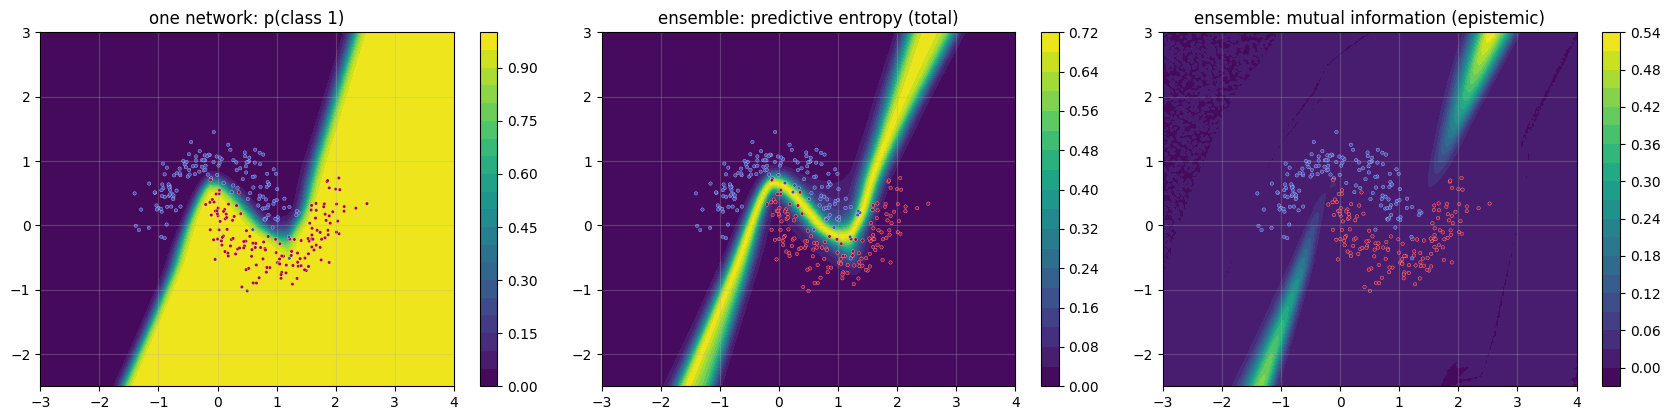

In [3]:
Xm, ym = make_moons(300, noise=0.2, random_state=0)
moons = train_ensemble(Xm, ym, M=8, epochs=300)

g1, g2 = np.meshgrid(np.linspace(-3, 4, 200), np.linspace(-2.5, 3, 200))
G = np.c_[g1.ravel(), g2.ravel()]
p_bar, H, MI, P = predict(moons, G)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
for a, Z, title in [(ax[0], P[0][:, 1], "one network: p(class 1)"),
                    (ax[1], H, "ensemble: predictive entropy (total)"),
                    (ax[2], MI, "ensemble: mutual information (epistemic)")]:
    cs = a.contourf(g1, g2, Z.reshape(g1.shape), levels=20, cmap="viridis"); plt.colorbar(cs, ax=a)
    a.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", s=6, edgecolor="w", lw=0.2); a.set_title(title)
plt.tight_layout(); plt.show()

**A limitation worth seeing.** In the far corners of the plot, away from all training points, the MI is close to zero: every member confidently predicts one class. ReLU networks become *more* confident as inputs move far from the data (Hein et al., 2019), and ensembles or MC dropout inherit this. Epistemic uncertainty from approximate BNNs is informative, but it is not a guarantee.

## 2. Breast-cancer diagnosis

569 tumours, 30 features computed from cell-nucleus images. In scikit-learn the target is 0 = malignant, 1 = benign; we recode so that **1 = malignant** (the positive, dangerous class).

In [4]:
data = load_breast_cancer()
X, y = data.data, (data.target == 0).astype(int)        # 1 = malignant
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.4, stratify=y, random_state=1)
scaler = StandardScaler().fit(X_tr)
X_tr, X_te = scaler.transform(X_tr), scaler.transform(X_te)
print(f"train {len(y_tr)}, test {len(y_te)}, malignant fraction {y.mean():.2f}")

members = train_ensemble(X_tr, y_tr, M=8)
p_bar, H, MI, P = predict(members, X_te)
p_single = P[0]

train 341, test 228, malignant fraction 0.37


### Accuracy is not enough: calibration

* **NLL** (log loss) and **Brier score** reward probabilities that are both right and honest.
* **Expected calibration error (ECE)**: bin predictions by confidence and compare confidence with actual accuracy.

In [5]:
def metrics(p, y, bins=10):
    pred = p.argmax(1); conf = p.max(1)
    acc = (pred == y).mean()
    nll = -np.log(np.clip(p[np.arange(len(y)), y], 1e-12, 1)).mean()
    brier = ((p[:, 1] - y) ** 2).mean()
    edges = np.linspace(0.5, 1, bins + 1); ece = 0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.any():
            ece += mask.mean() * abs((pred[mask] == y[mask]).mean() - conf[mask].mean())
    return acc, nll, brier, ece

print(f"{'model':16s} {'accuracy':>8s} {'NLL':>7s} {'Brier':>7s} {'ECE':>7s}")
for name, p in [("single network", p_single), ("ensemble (BNN≈)", p_bar)]:
    print(f"{name:16s} " + " ".join(f"{v:7.3f}" for v in metrics(p, y_te)))

model            accuracy     NLL   Brier     ECE
single network     0.965   0.150   0.029   0.031
ensemble (BNN≈)    0.969   0.143   0.027   0.028


## 3. Safety-critical use: refer the uncertain cases

A diagnostic system does not have to decide every case. Rank test cases by predictive entropy, let the model decide the most certain fraction (the **coverage**) and refer the rest to a clinician.
If the uncertainty is meaningful, accuracy on the decided cases should rise as coverage falls.

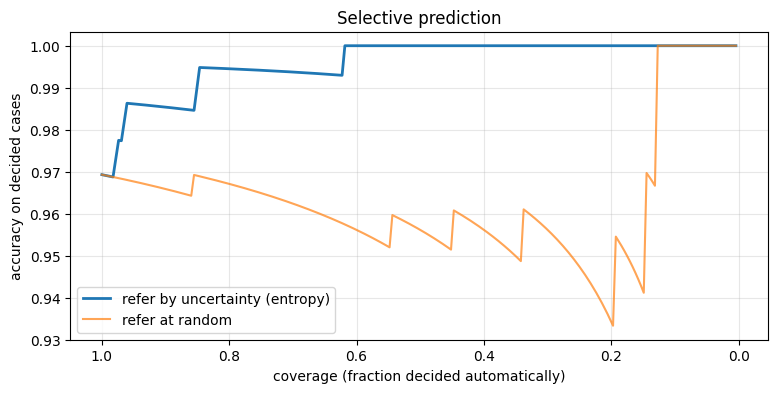

decide 100% of cases -> accuracy 0.969  (0 referred)
decide 90% of cases -> accuracy 0.985  (23 referred)
decide 80% of cases -> accuracy 0.995  (46 referred)


In [6]:
def accuracy_coverage(p, unc, y):
    order = np.argsort(unc)                          # most certain first
    correct = (p.argmax(1) == y)[order]
    cov = np.arange(1, len(y) + 1) / len(y)
    return cov, np.cumsum(correct) / np.arange(1, len(y) + 1)

cov, acc = accuracy_coverage(p_bar, H, y_te)
cov_r, acc_r = accuracy_coverage(p_bar, rng.random(len(y_te)), y_te)
plt.plot(cov, acc, lw=2, label="refer by uncertainty (entropy)")
plt.plot(cov_r, acc_r, alpha=0.7, label="refer at random")
plt.gca().invert_xaxis(); plt.xlabel("coverage (fraction decided automatically)"); plt.ylabel("accuracy on decided cases")
plt.legend(); plt.title("Selective prediction"); plt.show()

for c in [1.0, 0.9, 0.8]:
    k = int(c * len(y_te)) - 1
    print(f"decide {c:.0%} of cases -> accuracy {acc[k]:.3f}  ({len(y_te) - k - 1} referred)")

## 4. Making better decisions: unequal costs

Suppose a missed cancer (false negative) costs **10** units and an unnecessary biopsy (false positive) costs **1**. Bayesian decision theory says: choose the action with the lowest *expected* cost under the predictive distribution,

$$\text{treat as malignant if}\quad p\cdot C_{FN} > (1-p)\cdot C_{FP}\iff p > \frac{C_{FP}}{C_{FP}+C_{FN}}=\frac1{11}\approx0.09 .$$

This only works if $p$ is a trustworthy probability — which is exactly what calibration measured above.

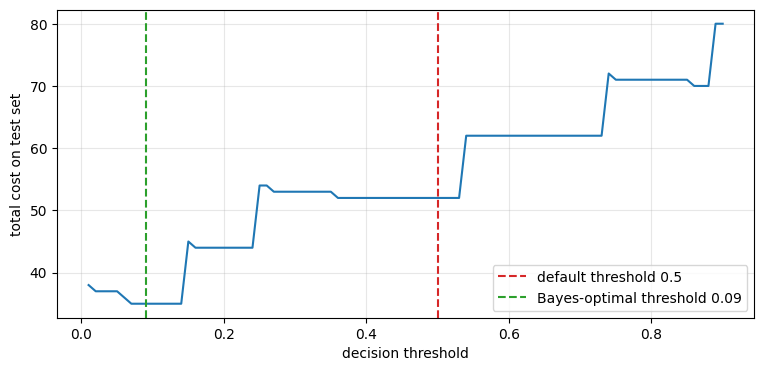

threshold 0.5 : cost  52   missed cancers 5   false alarms 2
Bayes-optimal : cost  35   missed cancers 3   false alarms 5


In [7]:
C_FN, C_FP = 10, 1
def total_cost(p_malignant, y, threshold):
    pred = (p_malignant > threshold).astype(int)
    fn = ((pred == 0) & (y == 1)).sum(); fp = ((pred == 1) & (y == 0)).sum()
    return C_FN * fn + C_FP * fp, fn, fp

thresholds = np.linspace(0.01, 0.9, 90)
costs = [total_cost(p_bar[:, 1], y_te, t)[0] for t in thresholds]
t_bayes = C_FP / (C_FP + C_FN)

plt.plot(thresholds, costs)
plt.axvline(0.5, c="C3", ls="--", label="default threshold 0.5")
plt.axvline(t_bayes, c="C2", ls="--", label=f"Bayes-optimal threshold {t_bayes:.2f}")
plt.xlabel("decision threshold"); plt.ylabel("total cost on test set"); plt.legend(); plt.show()

for name, t in [("threshold 0.5", 0.5), ("Bayes-optimal", t_bayes)]:
    c, fn, fp = total_cost(p_bar[:, 1], y_te, t)
    print(f"{name:14s}: cost {c:3d}   missed cancers {fn}   false alarms {fp}")

## 5. Detecting unusual inputs

What if a sample comes from a different scanner, or a data-entry error scales some features? We simulate **out-of-distribution (OOD)** inputs by perturbing test cases strongly and compare the epistemic uncertainty (mutual information).

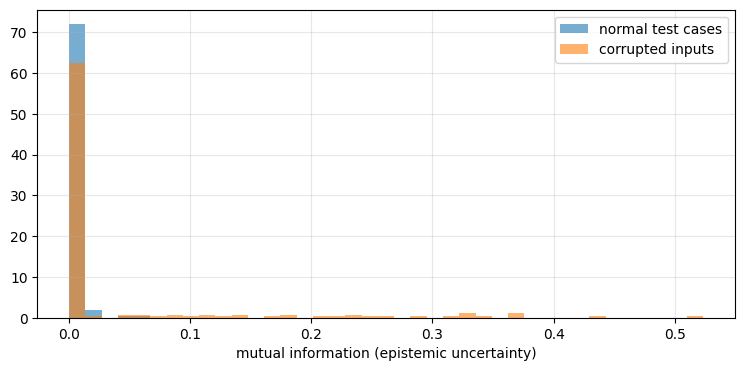

flagged as unusual: 5% of normal cases, 17% of corrupted cases


In [8]:
X_ood = X_te + rng.normal(0, 3, X_te.shape)             # heavily corrupted measurements
_, H_ood, MI_ood, _ = predict(members, X_ood)

bins = np.linspace(0, max(MI.max(), MI_ood.max()), 40)
plt.hist(MI, bins=bins, alpha=0.6, density=True, label="normal test cases")
plt.hist(MI_ood, bins=bins, alpha=0.6, density=True, label="corrupted inputs")
plt.xlabel("mutual information (epistemic uncertainty)"); plt.legend(); plt.show()

thr = np.quantile(MI, 0.95)
print(f"flagged as unusual: {np.mean(MI > thr):.0%} of normal cases, {np.mean(MI_ood > thr):.0%} of corrupted cases")

Epistemic uncertainty flags the corrupted inputs more often than normal ones, but it catches only part of them — consistent with the limitation seen on the moons data. OOD detection with approximate BNNs is useful but far from perfect; in a real system it is combined with input validation and monitoring.

## Summary: where BNNs earn their cost
* **Medicine, autonomous systems, finance, science** — any setting where a wrong confident answer is expensive.
* **Human-in-the-loop** workflows that refer uncertain cases.
* **Decisions with asymmetric costs**, which need calibrated probabilities.
* **Active learning** — label the points the model is most uncertain about.

## Exercises
1. Replace the ensemble by MC dropout (a single network, dropout kept on at prediction time). Compare NLL, ECE and the selective-prediction curve.
2. Use mutual information instead of entropy for referral. Which works better here, and why?
3. Change the costs to $C_{FN}=50$. How many biopsies does the optimal policy order now?
4. **Active learning**: start with 20 labelled training points and repeatedly add the pool point with the highest MI. Compare the accuracy curve with random selection.